# **Notebook 2: Data Preprocessing & Merging**

> **Objective:** Transform raw customer demographics and transactional basket data into a unified, model-ready master dataset. Heavy lifting and pipeline steps are modularly executed via our centralized `datacleaning.py` script.

---

## **Table of Contents**
1. [Imports and Libraries](#1-imports)
2. [Load Raw Datasets](#2-load)
3. [Execute Independent Cleaning Pipelines](#3-pipelines)
4. [Merging the Two Clean Datasets (Inner Join)](#4-merge)
5. [Validation Checks](#5-validation)
6. [Export Final Data](#6-export)

---

## **Imports and Libraries**

In [1]:
import sys
sys.path.append('../src')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.metrics import silhouette_score, silhouette_samples, confusion_matrix, adjusted_rand_score
from datacleaning import customer_handle_missing_values


from utils import (
    scaling,
    plot_dendrogram,
    visualize_dimensionality_reduction
)


from clustering import(
    plot_silhouette,
    plot_elbow,
    print_silhouette_scores,
    apply_kmeans_perc,
    apply_kmeans_lifetime,
    cluster_groupby
)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
dataset = pd.read_csv('../data/clean_customer_info.csv', index_col= 0)

dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,year_first_transaction,years_tenure,distinct_stores_visited,...,perc_spend_vegetables,perc_spend_meat_fish,perc_spend_petfood,perc_spend_tech_entertainment,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,2020,6,3,...,0.020065,0.012964,0.020656,0.258687,0.631038,0.009521,0.029693,38.794428,-9.215739,0
4,Glenda Bauman,female,51,Bsc,1,0,1,2013,13,2,...,0.099442,0.002867,0.032867,0.064054,0.676815,0.004695,0.092918,38.751711,-9.179611,0
5,Antonio Campbell,male,55,Msc,0,0,0,2005,21,2,...,0.035694,0.098913,0.014277,0.006496,0.797929,0.007589,0.032607,38.780678,-9.160656,0
7,John Kelling,male,44,Unknown,0,0,0,2021,5,1,...,0.005618,0.137440,0.012306,0.184658,0.501137,0.075776,0.032437,38.739548,-9.148679,0
8,Arthur Dematteo,male,57,Unknown,0,0,0,2021,5,1,...,0.014730,0.080746,0.017095,0.469008,0.356127,0.027833,0.011513,38.733071,-9.188188,0


## **2. Feature Selection and Pre-Processing**

Regarding the features we used for the clustering, after **several tries with different combinations**, we ended up choosing the ones in the cell below. 

This section contemplates both demographic variables (`customer_age`, `total_children`, `years_tenure`) and behavioral metrics (`spend percentages`, `number_complaints`, `percentage_of_products_bought_promotion`). This approach allows the K-Means algorithm to capture and differentiate customers with similar shopping tendencies but with different life stages. 

##### **2.1. 'Lifetime Spend' vs Percentage Spend**
A critical data engineering decision was to utilize relative **percentage spending instead of absolute lifetime spend** metrics (e.g., using perc_spend_vegetables rather than lifetime_spend_vegetables).

If absolute values had been used, the K-Means would be biased by overall purchasing power, simply dividing the database into "Rich Customers" vs. "Poor Customers". By converting the data into percentages, we "normalize" the shopping basket. This forces the algorithm to group customers based on their lifestyle preferences and tastes (e.g., identifying a strict Vegetarian), regardless of whether their total budget is large or small. 

##### **2.2. Removing Uninformative Categories**

Some features were purposely **excluded** from the final feature selection like, the groceries, pet food and alcohol. After several tries to improve our clustering, these variables showed **low variance or no pattern across our customers**. They would act more as statistical **noise** rather than differentiating factors, that way, the algortihm only focuses on the features that truly segmentate our customers.


Geospatial variables (latitude, longitude) were also **excluded** to prevent the model from creating regional bias, reserving them for later profiling.

In [ ]:
dataset_perc = dataset.copy()

In [ ]:
features_perc = [
    'customer_age',
    'number_complaints',
    'total_children',
    'years_tenure',
    'distinct_stores_visited',

    'percentage_of_products_bought_promotion',
    'perc_spend_vegetables',
    'perc_spend_meat_fish',
    'perc_spend_tech_entertainment',
    'perc_spend_hygiene'
]

X_perc = dataset_perc[features_perc].copy()
X_perc.columns

Index(['customer_age', 'number_complaints', 'total_children', 'years_tenure',
       'distinct_stores_visited', 'percentage_of_products_bought_promotion',
       'perc_spend_vegetables', 'perc_spend_meat_fish',
       'perc_spend_tech_entertainment', 'perc_spend_hygiene'],
      dtype='str')

##### **2.3. Data Scaling**

The data was normalized using **StandardScaler**. Without standardization, features with larger numerical ranges (e.g., `customer_age` or `years_tenure`) would **disproportionately dominate** the distance calculations, lowering the impact of bounded features (such as `percentage_of_products_bought_promotion`, which strictly ranges from 0 to 1).

Also, as it was not necessary to use the `lifetime_spend` columns as they were originally, we did not use any log transformation
.


In [ ]:
X_scaled_perc = scaling(X_perc) #Standard Scaler

## **3. Determining the Optimal Number of Clusters (K)**

To determine the optimal number of clusters($K$), two strategies were used: the **Elbow Method** and the **Silhouette Score**.

#### **3.1. Elbow Method**

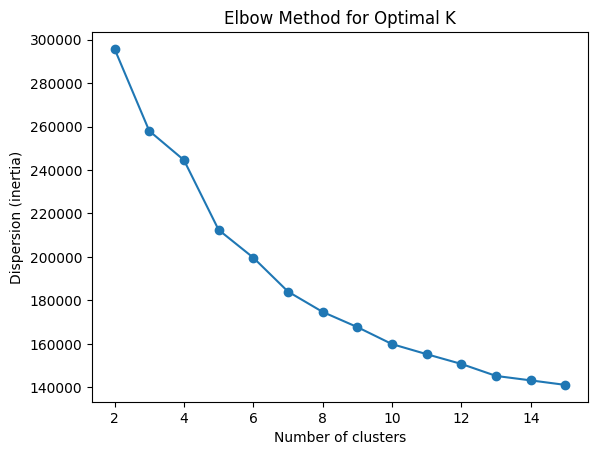

In [ ]:
plot_elbow(X_scaled_perc, k_range= 15)

The Elbow Method evaluates the **inertia** to measure cluster compactness. 
As observed in the plot, the inertia decreases smoothly **without** an "elbow" point. This indicates that while the variance continues to drop as K increases, the marginal gain diminishes after the mid-range values.

With all this information, theoretically, the "best" numbers of $K$ would maybe be between 8-10.

##### **3.2. Silhouette Score**

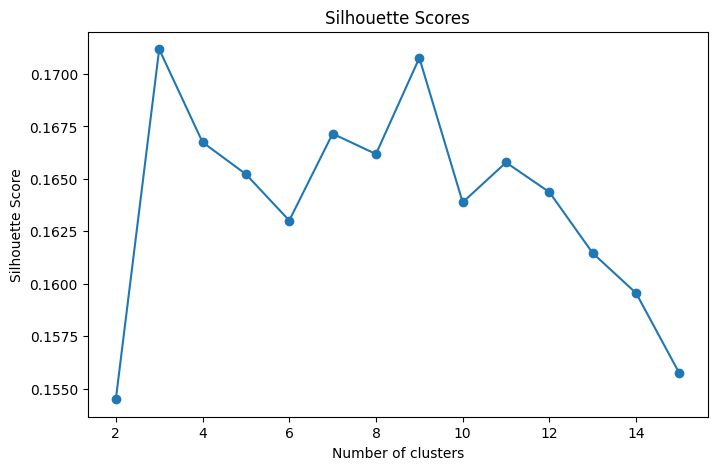

Evaluating Silhouette Scores:
k=7 | silhouette=0.1647
k=8 | silhouette=0.1640
k=9 | silhouette=0.1695
k=10 | silhouette=0.1640


In [ ]:
plot_silhouette(X_scaled_perc)
print_silhouette_scores(X_scaled_perc, k_values= [7,8,9,10])

The Silhouette Score measures **cluster cohesion**. The plot demonstrates a mathematical peak at lower values (e.g., K=2). However, we decided that selecting K=2 would result in severe **under-fitting**, as it would not be appropriate to divide the whole dataset in just 2 groups.

Although $K$ = 9 was the second best score, by looking at our customer data and after many analysis we conclude that choosing 9 clusters would create **over-segmentation** (e.g. the Vegetarians and the Hygiene were overlapping). Therefore, we chose **$K$** = 8 as our final choice.

## **4. K-Means Algorithm**

##### **4.1. How it Works**

The first algorithm we used was **K-Means**. Mathematically, it identifies $K$ centroids (the central points) in the data space. Then, assigns every customer to the centroid that most closely matches their unique purchasing habits. Through continuous iteration, the algorithm refines these groups until it achieves **maximum similarity inside** each cluster and **maximum variance between** clusters.

By setting the model to **$K=8$**, as defined before, the algorithm identifies eight different profiles that exist in the dataset.

In [ ]:
apply_kmeans(X_scaled_perc, dataset, X_perc, k = 8)

Customer Distribution for K=8:
cluster_kmeans
0    6612
1    2350
2    5416
3    4178
4    3029
5    5844
6    1673
7    3936
Name: count, dtype: int64


,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",8
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [ ]:
cluster_groupby(X_perc,cluster_kmeans= 'cluster_kmeans', method= 'mean')

Grouped by mean


cluster_kmeans,0,1,2,3,4,5,6,7
customer_age,63.722928,58.468511,58.190362,36.082097,57.279960,61.873546,59.036461,41.134654
number_complaints,0.574410,0.891915,0.651588,0.516276,1.063387,0.844798,0.937238,2.403709
total_children,1.732910,6.941702,1.927068,1.381283,0.555959,1.418891,1.573819,2.539126
years_tenure,14.502420,13.558723,10.421344,6.483006,8.898646,11.634155,11.466826,9.167683
distinct_stores_visited,2.514368,3.294894,3.538589,3.314983,1.443051,4.683778,3.671847,2.373476
percentage_of_products_bought_promotion,0.165131,0.203800,0.133337,0.295819,0.260300,0.656956,0.435972,0.446613
perc_spend_vegetables,0.030227,0.022957,0.127568,0.026144,0.007854,0.023162,0.055407,0.019301
perc_spend_meat_fish,0.054599,0.078748,0.015173,0.055617,0.076116,0.064068,0.190502,0.067840
perc_spend_tech_entertainment,0.077446,0.152887,0.110845,0.089119,0.495124,0.074147,0.159820,0.084232
perc_spend_hygiene,0.033418,0.026013,0.096795,0.031743,0.011033,0.030481,0.084930,0.029970


In [ ]:
cluster_groupby(X_perc, cluster_kmeans= 'cluster_kmeans', method= 'median')

Grouped by median


cluster_kmeans,0,1,2,3,4,5,6,7
customer_age,65.000000,58.000000,59.000000,32.000000,57.000000,63.000000,61.000000,34.000000
number_complaints,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,2.000000
total_children,2.000000,7.000000,2.000000,1.000000,0.000000,1.000000,1.000000,2.000000
years_tenure,14.000000,14.000000,10.000000,6.000000,9.000000,11.000000,11.000000,9.000000
distinct_stores_visited,2.000000,3.000000,4.000000,3.000000,1.000000,5.000000,4.000000,2.000000
percentage_of_products_bought_promotion,0.149580,0.200462,0.121398,0.234704,0.252005,0.659319,0.391727,0.406859
perc_spend_vegetables,0.021774,0.020970,0.112138,0.016229,0.005592,0.015472,0.041144,0.014818
perc_spend_meat_fish,0.053725,0.073741,0.011159,0.052872,0.072227,0.059953,0.175420,0.064894
perc_spend_tech_entertainment,0.062402,0.144844,0.082433,0.072818,0.493316,0.056628,0.128719,0.069894
perc_spend_hygiene,0.030104,0.024430,0.091801,0.027709,0.008724,0.027076,0.079625,0.027166


In [12]:
cluster_names = {
    0: "Older Long-Tenure",
    1: "Large Families",
    2: "Clean and Green",
    3: 'Young Most Recent Customer',
    4: "Tech Enthusiasts",
    5: "Promotion Seekers",
    6: "Protein Lovers",
    7: "Service Sensitive"
}


dataset['cluster_name'] = dataset['cluster_kmeans'].map(cluster_names)
dataset.head()

,customer_name,customer_gender,customer_age,education_level,kids_home,teens_home,total_children,year_first_transaction,years_tenure,distinct_stores_visited,...,perc_spend_petfood,perc_spend_tech_entertainment,perc_spend_groceries,perc_spend_alcohol,perc_spend_hygiene,latitude,longitude,is_customer_outlier,cluster_kmeans,cluster_name
customer_id,,,,,,,,,,,,,,,,,,,,,
3,Crystal Kitchens,female,56,Bsc,1,1,2,2020,6,3,...,0.020656,0.258687,0.631038,0.009521,0.029693,38.794428,-9.215739,0,3,Young Most Recent Customer
4,Glenda Bauman,female,51,Bsc,1,0,1,2013,13,2,...,0.032867,0.064054,0.676815,0.004695,0.092918,38.751711,-9.179611,0,2,Clean and Green
5,Antonio Campbell,male,55,Msc,0,0,0,2005,21,2,...,0.014277,0.006496,0.797929,0.007589,0.032607,38.780678,-9.160656,0,0,Older Long-Tenure
7,John Kelling,male,44,Unknown,0,0,0,2021,5,1,...,0.012306,0.184658,0.501137,0.075776,0.032437,38.739548,-9.148679,0,7,Service Sensitive
8,Arthur Dematteo,male,57,Unknown,0,0,0,2021,5,1,...,0.017095,0.469008,0.356127,0.027833,0.011513,38.733071,-9.188188,0,4,Tech Enthusiasts


## **5. Hierarchical Clustering**

In [ ]:
experimental_hierarchical = AgglomerativeClustering(linkage='ward', distance_threshold=0, n_clusters=None).fit(X_scaled_perc)

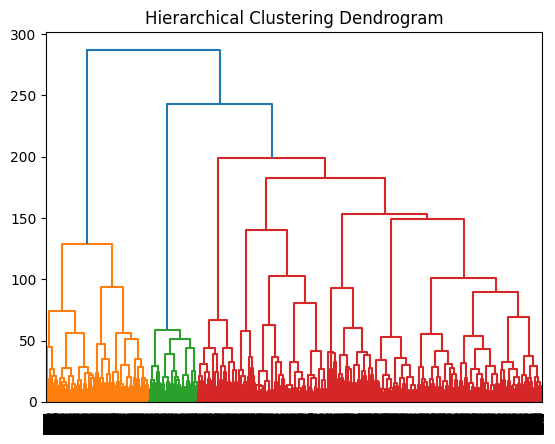

In [18]:
fig, ax = plt.subplots()
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(experimental_hierarchical, truncate_mode="level", p=50)
plt.show()


In [ ]:
scores = []

for k in range(2,K_range+1):
    experimental_hierarchical = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = experimental_hierarchical.fit_predict(X_scaled_perc)
    scores.append(silhouette_score(X_scaled_perc, labels))
        
plt.figure(figsize=(8, 5))
plt.plot(range(2,K_range+1), scores, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

NameError: name 'K_range' is not defined

In [ ]:
dataset['cluster_agglomerative'] = AgglomerativeClustering(linkage='ward', n_clusters=8).fit_predict(X_scaled_perc)

In [ ]:
dataset.columns

Index(['customer_name', 'customer_gender', 'customer_age', 'education_level',
       'kids_home', 'teens_home', 'total_children', 'year_first_transaction',
       'years_tenure', 'distinct_stores_visited', 'number_complaints',
       'typical_hour', 'time_of_day', 'lifetime_total_distinct_products',
       'percentage_of_products_bought_promotion', 'lifetime_spend_groceries',
       'lifetime_spend_vegetables', 'lifetime_spend_meat',
       'lifetime_spend_fish', 'lifetime_spend_meat_fish',
       'lifetime_spend_electronics_videogames', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_nonalcohol_drinks',
       'lifetime_spend_alcohol_drinks', 'lifetime_spend_hygiene',
       'lifetime_spend_petfood', 'total_spend', 'perc_spend_vegetables',
       'perc_spend_meat_fish', 'perc_spend_petfood',
       'perc_spend_tech_entertainment', 'perc_spend_groceries',
       'perc_spend_alcohol', 'perc_spend_hygiene', 'latitude', 'longitude',
       'is_customer_ou

In [ ]:
dataset.info()

<class 'pandas.DataFrame'>
Index: 33038 entries, 3 to 40000
Data columns (total 41 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   customer_name                            33038 non-null  str    
 1   customer_gender                          33038 non-null  str    
 2   customer_age                             33038 non-null  int64  
 3   education_level                          33038 non-null  str    
 4   kids_home                                33038 non-null  int64  
 5   teens_home                               33038 non-null  int64  
 6   total_children                           33038 non-null  int64  
 7   year_first_transaction                   33038 non-null  int64  
 8   years_tenure                             33038 non-null  int64  
 9   distinct_stores_visited                  33038 non-null  int64  
 10  number_complaints                        33038 non-null  int64

In [ ]:
pd.DataFrame(
    confusion_matrix(
        dataset['cluster_kmeans'],
        dataset['cluster_agglomerative']
    ),
    index=[f'K-Means {i} Cluster' for i in np.arange(0, 8)],
    columns=[f'Hierarchical {i} Cluster' for i in np.arange(0, 8)]
)

,Hierarchical 0 Cluster,Hierarchical 1 Cluster,Hierarchical 2 Cluster,Hierarchical 3 Cluster,Hierarchical 4 Cluster,Hierarchical 5 Cluster,Hierarchical 6 Cluster,Hierarchical 7 Cluster
K-Means 0 Cluster,1038,306,286,261,1798,105,2745,73
K-Means 1 Cluster,1,3,37,2134,94,3,6,72
K-Means 2 Cluster,5303,3,55,0,5,0,0,50
K-Means 3 Cluster,479,1644,194,152,1566,70,73,0
K-Means 4 Cluster,1,17,34,6,14,2947,9,1
K-Means 5 Cluster,22,285,932,14,4568,3,14,6
K-Means 6 Cluster,3,51,1434,5,21,53,62,44
K-Means 7 Cluster,52,2489,71,67,259,58,6,934


In [ ]:

ari = adjusted_rand_score(
    dataset['cluster_kmeans'],
    dataset['cluster_agglomerative']
)

print("Adjusted Rand Index:", round(ari, 3))

Adjusted Rand Index: 0.455


In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=0
)

tsne_transformation = tsne.fit_transform(X_scaled_perc)


c:\Users\laura\Desktop\ML II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


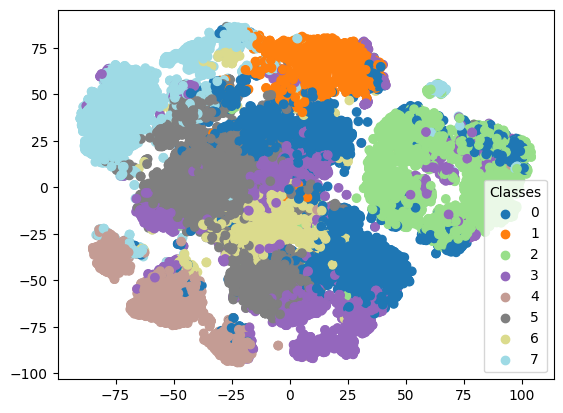

In [ ]:
visualize_dimensionality_reduction(tsne_transformation, dataset['cluster_kmeans'])    


In [ ]:
umap = UMAP(n_neighbors=50, random_state=0)

umap_transformation = umap.fit_transform(X_scaled_perc)

c:\Users\laura\Desktop\ML II\ml_project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [3]:
visualize_dimensionality_reduction(umap_transformation, dataset['cluster_kmeans'])

NameError: name 'umap_transformation' is not defined

## Export final customer clusters

The final K-Means segmentation is exported so it can be used in the association rules notebook and in the final project deliverables.

In [ ]:
dataset_export = dataset.reset_index()

In [ ]:
dataset_export[['customer_id', 'cluster_kmeans', 'cluster_name']].head()

,customer_id,cluster_kmeans,cluster_name
0,3,3,Young Most Recent Customer
1,4,2,Clean and Green
2,5,0,Older Long-Tenure
3,7,7,Service Sensitive
4,8,4,Tech Enthusiasts


In [ ]:
customer_clusters = dataset_export[['customer_id', 'cluster_kmeans', 'cluster_name']].copy()

customer_clusters.to_csv("../data/customer_clusters.csv", index=False)

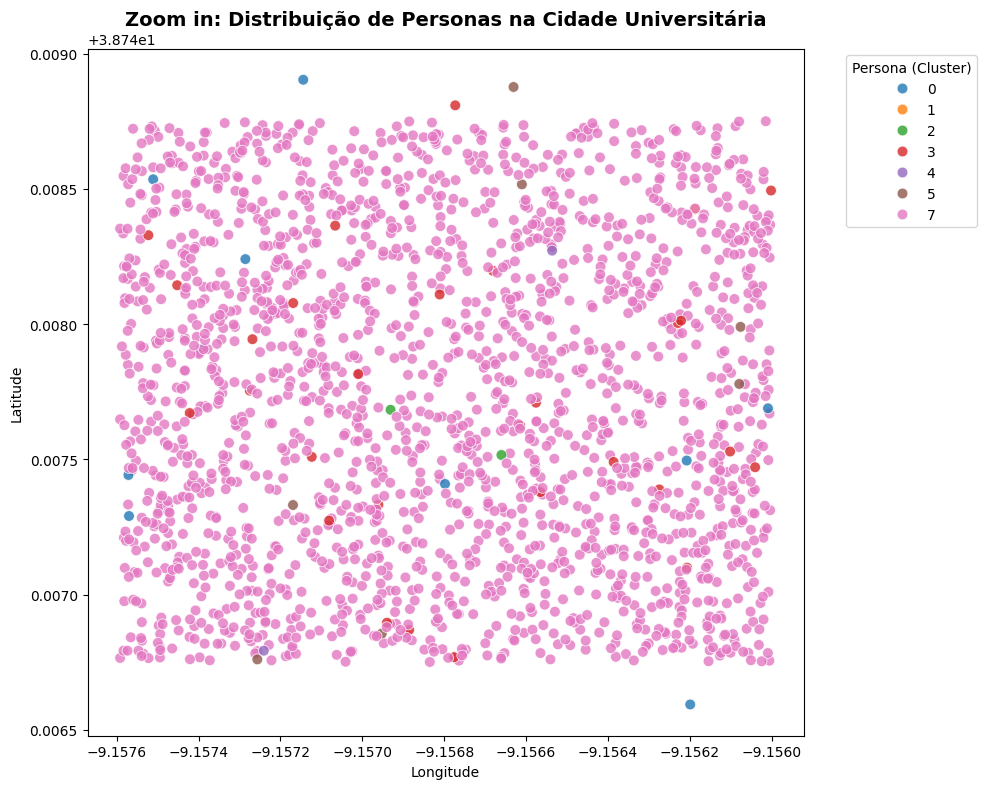

--- QUEM MORA NESTE QUADRADO SINTÉTICO? ---
Cluster 7: 1968 clientes (97.5%)
Cluster 3: 28 clientes (1.4%)
Cluster 0: 10 clientes (0.5%)
Cluster 5: 7 clientes (0.3%)
Cluster 4: 2 clientes (0.1%)
Cluster 2: 2 clientes (0.1%)
Cluster 1: 1 clientes (0.0%)


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# PASSO 1: LIMITES DO QUADRADO (Ajusta os valores olhando para os eixos do teu mapa)
# ---------------------------------------------------------
lat_min = 38.7465  # Ponto mais baixo do quadrado (Latitude)
lat_max = 38.749  # Ponto mais alto do quadrado (Latitude)
lon_min = -9.1576  # Ponto mais à esquerda (Longitude)
lon_max = -9.156  # Ponto mais à direita (Longitude)

# ---------------------------------------------------------
# PASSO 2: CORTAR O DATASET (Ficar apenas com quem vive no quadrado)
# ---------------------------------------------------------
mini_cluster_data = dataset[
    (dataset['latitude'] >= lat_min) & (dataset['latitude'] <= lat_max) &
    (dataset['longitude'] >= lon_min) & (dataset['longitude'] <= lon_max)
].copy()

# ---------------------------------------------------------
# PASSO 3: DESENHAR O MAPA COM ZOOM E CORES
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=mini_cluster_data,
    x='longitude',
    y='latitude',
    hue='cluster_kmeans', # Vai usar os teus 8 grupos finais
    palette='tab10',      # Paleta de cores bem contrastante
    s=60,                 # Pontos maiores porque fizemos zoom
    alpha=0.8
)

plt.title('Zoom in: Distribuição de Personas na Cidade Universitária', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Persona (Cluster)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PASSO 4: A VERDADE MATEMÁTICA (Imprime as percentagens na consola)
# ---------------------------------------------------------
print("--- QUEM MORA NESTE QUADRADO SINTÉTICO? ---")
if len(mini_cluster_data) == 0:
    print("Aviso: O quadrado está vazio. Afina os valores de lat_min/max e lon_min/max no Passo 1!")
else:
    contagem = mini_cluster_data['cluster_kmeans'].value_counts()
    percentagens = mini_cluster_data['cluster_kmeans'].value_counts(normalize=True) * 100
    
    for cluster, qtd in contagem.items():
        print(f"Cluster {cluster}: {qtd} clientes ({percentagens[cluster]:.1f}%)")

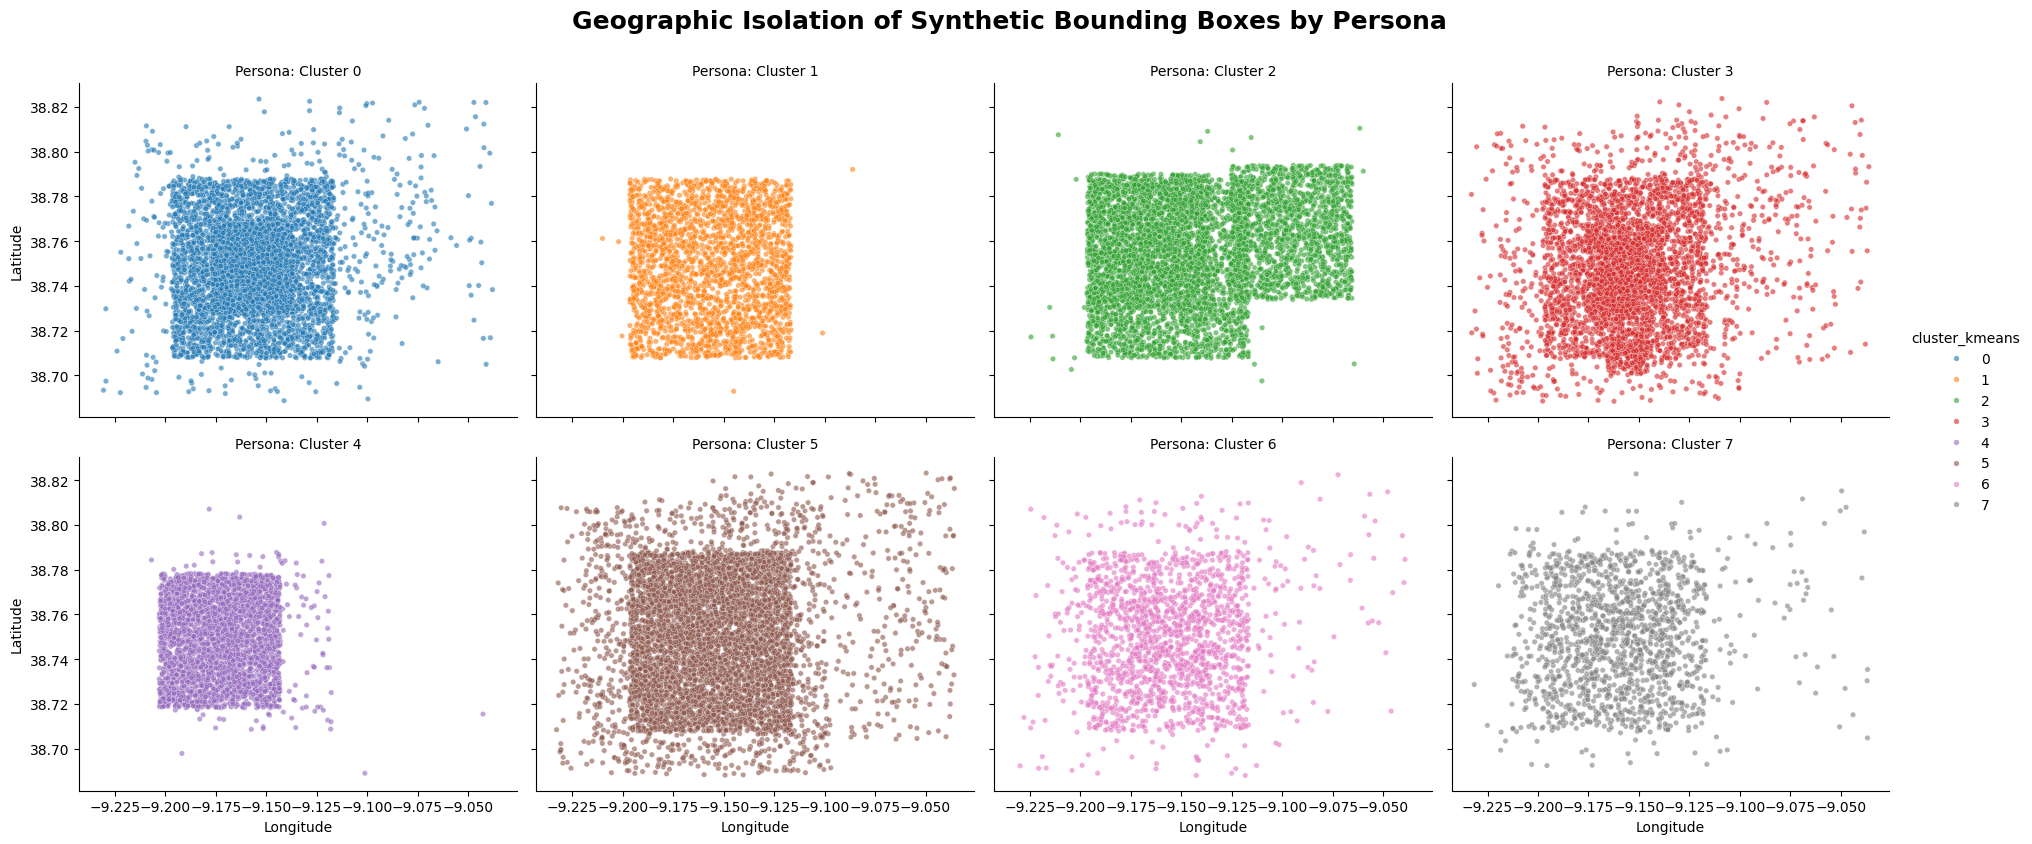

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using relplot to create a grid: one map per cluster
g = sns.relplot(
    data=dataset,
    x='longitude',
    y='latitude',
    col='cluster_kmeans', # This splits the data into separate plots!
    col_wrap=4,           # Defines 4 maps per row
    hue='cluster_kmeans',
    palette='tab10',
    s=15,                 # Dot size
    alpha=0.6,            # Transparency
    height=4,             # Height of each individual map
    aspect=1.2            # Width ratio
)

# Formatting for the university report
g.fig.suptitle('Geographic Isolation of Synthetic Bounding Boxes by Persona', y=1.05, fontsize=18, fontweight='bold')
g.set_axis_labels('Longitude', 'Latitude')
g.set_titles('Persona: Cluster {col_name}') # Names each subplot automatically

plt.show()

In [10]:
dataset_lifetime = dataset.copy()

In [11]:
features_lifetime = [
    'customer_age',
    'number_complaints',
    'kids_home',
    'teens_home',

    'percentage_of_products_bought_promotion',
    'lifetime_spend_vegetables',
    'lifetime_spend_meat_fish',
    'lifetime_spend_electronics',
    'lifetime_spend_videogames',
    'lifetime_spend_hygiene',
    'lifetime_spend_alcohol_drinks',
]

X_lifetime = dataset_lifetime[features_lifetime].copy()  
X_lifetime.columns

Index(['customer_age', 'number_complaints', 'kids_home', 'teens_home',
       'percentage_of_products_bought_promotion', 'lifetime_spend_vegetables',
       'lifetime_spend_meat_fish', 'lifetime_spend_electronics',
       'lifetime_spend_videogames', 'lifetime_spend_hygiene',
       'lifetime_spend_alcohol_drinks'],
      dtype='object')

In [4]:
X_scaled_lifetime = scaling(X_lifetime) #Standard Scaler

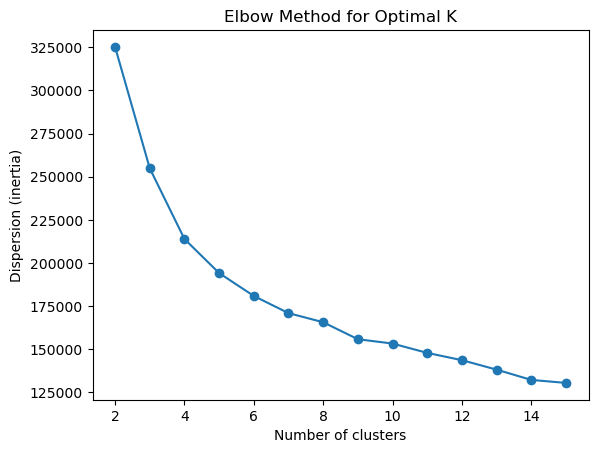

In [5]:
plot_elbow(X_scaled_lifetime, k_range= 15)

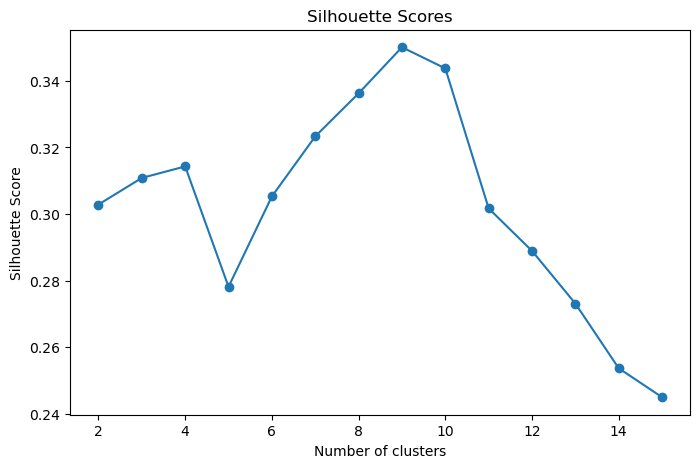

Evaluating Silhouette Scores:
k=7 | silhouette=0.3242
k=8 | silhouette=0.3376
k=9 | silhouette=0.3506
k=10 | silhouette=0.3430


In [9]:
plot_silhouette(X_scaled_lifetime)
print_silhouette_scores(X_scaled_lifetime, k_values= [7,8,9,10])

In [ ]:
X_scaled_lifetime = pd.DataFrame(X_scaled_lifetime, columns=X_lifetime.columns, index=X_lifetime.index)

apply_kmeans_lifetime(X_scaled_lifetime, dataset, X_lifetime, k = 9)

Customer Distribution for K=9:
cluster_kmeans
0    3661
1    4939
2    1168
3    6788
4    3278
5    3286
6    2881
7    3249
8    3788
Name: count, dtype: int64


,n_clusters,9
,init,'k-means++'
,n_init,10
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [7]:
cluster_groupby(X_scaled_lifetime,cluster_kmeans= 'cluster_kmeans', method= 'mean')

Grouped by mean


cluster_kmeans,0,1,2,3,4,5,6,7,8
customer_age,0.150369,0.066008,0.643677,0.073508,0.090507,-1.193887,0.111253,0.111179,0.215784
number_complaints,-0.196014,-0.258223,2.794327,-0.571588,0.152721,1.085122,-0.062808,-0.444499,0.044333
kids_home,-0.069738,-0.450524,0.189790,-0.435861,-0.744484,0.610145,2.095728,-0.060083,-0.050078
teens_home,0.003036,-0.389884,0.491434,-0.196703,-0.604198,-0.354215,2.043525,-0.034931,0.012237
percentage_of_products_bought_promotion,-0.791204,1.586455,-0.020083,-0.541364,-0.232202,0.615353,-0.436585,-0.607856,0.193022
lifetime_spend_vegetables,1.965689,-0.438182,-0.259991,-0.324376,-0.806926,-0.701055,0.172426,1.177723,-0.501869
lifetime_spend_meat_fish,-1.292362,-0.179951,0.419992,0.039920,0.498311,-0.357720,1.685116,-1.162994,0.877597
lifetime_spend_electronics,-0.215393,-0.483672,-0.243998,-0.451145,2.139071,-0.455338,0.652046,-0.546911,0.239573
lifetime_spend_videogames,-0.292834,-0.284404,-0.252918,-0.345376,2.517798,-0.461873,0.099512,-0.482966,-0.088861
lifetime_spend_hygiene,-0.187923,-0.560958,-0.114710,-0.205617,-0.897865,-0.610027,0.138180,1.982470,0.817550


In [8]:
cluster_groupby(X_lifetime,cluster_kmeans= 'cluster_kmeans', method= 'mean')

Grouped by mean


cluster_kmeans,0,1,2,3,4,5,6,7,8
customer_age,57.812346,56.290950,66.708904,56.426193,56.732764,33.569385,57.106907,57.105571,58.992080
number_complaints,0.756897,0.701559,3.416952,0.422805,1.067114,1.896531,0.875390,0.535857,0.970697
kids_home,1.036329,0.599717,1.333904,0.616529,0.262660,1.815886,3.519264,1.047399,1.058870
teens_home,0.901939,0.524803,1.370719,0.710224,0.319097,0.559038,2.860465,0.865497,0.910771
percentage_of_products_bought_promotion,0.105969,0.755673,0.316681,0.174239,0.258718,0.490316,0.202870,0.156070,0.374913
lifetime_spend_vegetables,2002.151871,425.230006,542.121575,499.885386,183.336181,252.786671,825.784103,1485.252078,383.451690
lifetime_spend_meat_fish,163.468451,1141.543025,1669.035103,1334.861815,1737.896278,985.241631,2781.380423,277.213912,2071.378828
lifetime_spend_electronics,1966.794592,1043.849970,1868.386986,1155.747790,10066.725442,1141.324711,4950.997570,826.292090,3531.989440
lifetime_spend_videogames,231.969134,235.839846,250.296233,207.845315,1522.434411,154.356969,412.109684,144.672515,325.620908
lifetime_spend_hygiene,697.381043,469.555781,742.095034,686.574838,263.794692,439.587340,896.543561,2022.916590,1311.458817


In [42]:
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate="auto",
    init="pca",
    random_state=0
)

tsne_transformation = tsne.fit_transform(X_scaled_lifetime)

c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


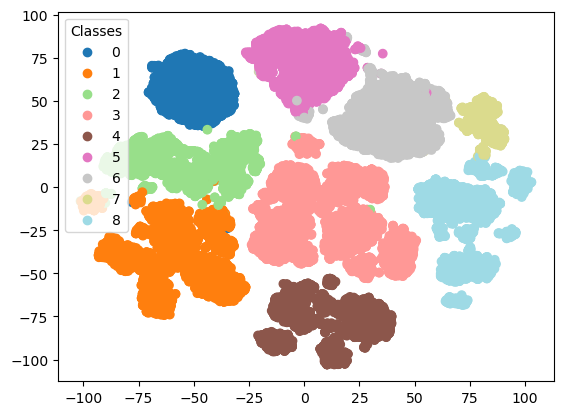

In [43]:
visualize_dimensionality_reduction(tsne_transformation, dataset['cluster_kmeans'])    


In [44]:
umap = UMAP(n_neighbors=50, random_state=0)



umap_transformation = umap.fit_transform(X_scaled_lifetime)

c:\Users\tiago\anaconda3\envs\Machinelearning\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\tiago\OneDrive - NOVAIMS\2ºano 2º semestre\Machine Learning II\ml_project\notebooks\../src\utils.py:85: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=rgba, label=label) for rgba, label in zip(rgba_values, labels)]


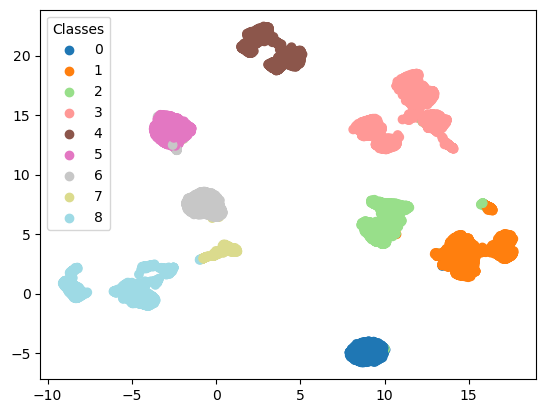

In [45]:
visualize_dimensionality_reduction(umap_transformation, dataset['cluster_kmeans'])